# PROYECTO INTEGRADOR: Fuga de Clientes con Segmentación de Valor (Customer Churn)
## Cuaderno 02: Preparación Reproducible, Baselines y Modelos Preliminares

**Curso:** Data Mining Tools (CC209) — UPC  
**Fase:** Trabajo Parcial (TP1) — Semana 7  
**Docente:** Carlos Fernando Montoya Cubas  

---

### Objetivos del cuaderno

1. **Reducir el riesgo de data leakage:** separar los datos antes de ajustar transformaciones estadísticas y mantener Test fuera de la selección de modelos.
2. **Implementar un flujo reproducible:** reutilizar las funciones de `src/` para que notebook y scripts compartan la misma lógica.
3. **Comparar modelos preliminares:** contrastar Regresión Logística y Random Forest usando Validation.
4. **Evaluar contra baselines:** comparar el modelo seleccionado con un baseline trivial y un baseline heurístico.
5. **Interpretar métricas en contexto:** priorizar PR-AUC por el desbalance de clases y complementar con Recall, Precision, F1, ROC-AUC y una simulación económica.
6. **Documentar limitaciones y próximos pasos:** dejar explícito qué queda pendiente para el Trabajo Final.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

# Detectar la raíz del proyecto tanto si el notebook se ejecuta
# desde /notebooks como desde la raíz del repositorio.
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from src.preprocessing import (
    load_raw_dataset,
    split_data,
    build_preprocessor
)

from src.evaluation import (
    evaluate_classifier,
    BusinessRuleBaseline
)

from src.train_models import build_candidate_models

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("Entorno y módulos cargados exitosamente.")

Entorno y módulos cargados exitosamente.


### 1. Carga de datos y estrategia de partición

El dataset se divide antes de ajustar cualquier transformación estadística utilizada por los modelos.

Se utilizan tres conjuntos:

- **Train (70%)**: se utiliza para ajustar el preprocesamiento y entrenar los modelos.
- **Validation (15%)**: se utiliza para comparar las alternativas de modelamiento y seleccionar el candidato preliminar.
- **Test (15%)**: se reserva hasta después de seleccionar el modelo y se utiliza para la evaluación final.

La partición se realiza de forma estratificada para conservar aproximadamente la prevalencia de `Churn` en los tres conjuntos.

In [2]:
# Carga del dataset mediante la función centralizada del proyecto.
df = load_raw_dataset()

# Partición estratificada:
# 70% Train / 15% Validation / 15% Test.
(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test
) = split_data(df)

print(f"Dataset completo: {len(df)} clientes")
print()

print(
    f"Train:      {len(X_train)} filas "
    f"| Churn Rate: {y_train.mean():.2%}"
)

print(
    f"Validation: {len(X_val)} filas "
    f"| Churn Rate: {y_val.mean():.2%}"
)

print(
    f"Test:       {len(X_test)} filas "
    f"| Churn Rate: {y_test.mean():.2%}"
)

print()
print(
    "Valores faltantes en TotalCharges después "
    f"de aplicar la regla lógica: "
    f"{df['TotalCharges'].isna().sum()}"
)

Dataset completo: 7043 clientes

Train:      4930 filas | Churn Rate: 26.53%
Validation: 1056 filas | Churn Rate: 26.52%
Test:       1057 filas | Churn Rate: 26.58%

Valores faltantes en TotalCharges después de aplicar la regla lógica: 0


> **Justificación metodológica de la partición**
>
> Se utiliza una estrategia **70% Train / 15% Validation / 15% Test** con estratificación sobre `Churn`.
>
> La separación de Validation permite comparar modelos sin utilizar Test para tomar decisiones. La estratificación mantiene la proporción de fuga cercana al 26.5% en los tres conjuntos y `random_state=42` permite reproducir la partición.
>
> Las estadísticas del preprocesamiento —medianas, escalas y categorías observadas por `OneHotEncoder`— se ajustan dentro del `Pipeline`, de modo que se aprenden únicamente a partir de los datos usados para entrenamiento en cada etapa.

### 2. Calidad de datos y regla lógica para `TotalCharges`

En el EDA se detectaron 11 registros vacíos en `TotalCharges`. Todos corresponden a clientes con `tenure = 0`, por lo que el proyecto aplica una regla lógica: esos casos se representan con `TotalCharges = 0`.

Esta corrección no estima un parámetro estadístico a partir del conjunto completo. Si apareciera otro faltante numérico inesperado, el `SimpleImputer(strategy="median")` del pipeline actuaría como respaldo y aprendería la mediana únicamente de los datos de entrenamiento.

In [3]:
resumen_calidad = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "faltantes": df.isna().sum(),
    "n_unicos": df.nunique(dropna=False)
})

print("Duplicados completos:", df.duplicated().sum())
print("Filas totales:", len(df))
print()
display(resumen_calidad)

Duplicados completos: 0
Filas totales: 7043



,dtype,faltantes,n_unicos
customerID,str,0,7043
gender,str,0,2
SeniorCitizen,str,0,2
Partner,str,0,2
Dependents,str,0,2
tenure,int64,0,73
PhoneService,str,0,2
MultipleLines,str,0,3
InternetService,str,0,3
OnlineSecurity,str,0,3


### 3. Preprocesamiento reproducible con `ColumnTransformer`

El proyecto reutiliza `build_preprocessor()` desde `src/preprocessing.py`.

- **Numéricas:** `SimpleImputer(strategy="median")` + `StandardScaler`.
- **Categóricas:** `SimpleImputer(strategy="most_frequent")` + `OneHotEncoder(drop="first", handle_unknown="ignore")`.

El uso de un `Pipeline` evita ajustar manualmente estas transformaciones sobre Validation o Test.

In [4]:
preprocessor = build_preprocessor()
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### 4. Modelos candidatos y criterio de selección

Se comparan dos alternativas apropiadas para clasificación binaria:

1. **Regresión Logística balanceada:** alternativa lineal e interpretable.
2. **Random Forest balanceado:** alternativa no lineal basada en ensambles de árboles.

Ambos modelos se entrenan exclusivamente con Train y se comparan sobre Validation.

**Métrica principal de selección: PR-AUC.**  
Se prioriza porque la clase positiva (`Churn = 1`) es minoritaria (~26.5%) y se desea evaluar la calidad del ranking de clientes en riesgo sin depender únicamente de Accuracy.

Recall, Precision, F1, ROC-AUC y la simulación económica se usan como métricas complementarias.

In [5]:
candidate_models = build_candidate_models()

validation_results = []
validation_probas = {}

for name, model in candidate_models.items():
    model.fit(X_train, y_train)

    result = evaluate_classifier(
        model,
        X_val,
        y_val,
        model_name=name
    )

    validation_results.append(result)
    validation_probas[name] = model.predict_proba(X_val)[:, 1]

df_validation = pd.DataFrame(validation_results)

display_cols = [
    "Modelo",
    "Accuracy",
    "Precision (Clase 1)",
    "Recall (Clase 1)",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC",
    "TN",
    "FP",
    "FN",
    "TP",
    "Valor Económico Neto ($)"
]

display(
    df_validation[display_cols]
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)

,Modelo,Accuracy,Precision (Clase 1),Recall (Clase 1),F1-Score,ROC-AUC,PR-AUC,TN,FP,FN,TP,Valor Económico Neto ($)
0,"Random Forest (Balanced, depth=10)",0.768939,0.546392,0.757143,0.634731,0.841677,0.632703,600,176,68,212,31400.0
1,Regresión Logística (Balanced),0.740530,0.506667,0.814286,0.624658,0.844797,0.631277,554,222,52,228,42700.0


### 5. Visualización de desempeño en Validation

Las curvas ROC y Precision-Recall se construyen únicamente sobre Validation para comparar los modelos antes de seleccionar el candidato.

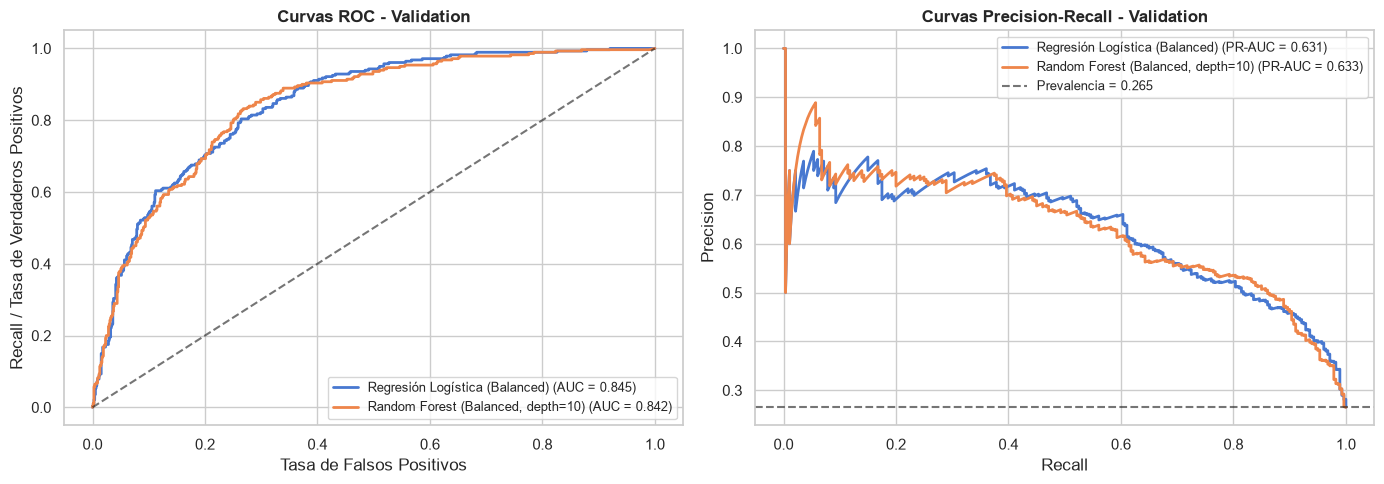

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for name, y_proba in validation_probas.items():
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc_val = roc_auc_score(y_val, y_proba)

    ax[0].plot(
        fpr,
        tpr,
        lw=2,
        label=f"{name} (AUC = {auc_val:.3f})"
    )

ax[0].plot([0, 1], [0, 1], "k--", alpha=0.6)
ax[0].set_title("Curvas ROC - Validation", fontweight="bold")
ax[0].set_xlabel("Tasa de Falsos Positivos")
ax[0].set_ylabel("Recall / Tasa de Verdaderos Positivos")
ax[0].legend(loc="lower right", fontsize=9)

for name, y_proba in validation_probas.items():
    precision, recall, _ = precision_recall_curve(y_val, y_proba)
    pr_val = average_precision_score(y_val, y_proba)

    ax[1].plot(
        recall,
        precision,
        lw=2,
        label=f"{name} (PR-AUC = {pr_val:.3f})"
    )

ax[1].axhline(
    y_val.mean(),
    color="k",
    linestyle="--",
    alpha=0.6,
    label=f"Prevalencia = {y_val.mean():.3f}"
)

ax[1].set_title("Curvas Precision-Recall - Validation", fontweight="bold")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

### 6. Selección del candidato preliminar

El modelo con mayor PR-AUC en Validation se selecciona automáticamente. Esto evita escoger el modelo a partir del rendimiento observado en Test.

In [7]:
best_row = df_validation.loc[
    df_validation["PR-AUC"].idxmax()
]

selected_model_name = best_row["Modelo"]

print("Modelo seleccionado:", selected_model_name)
print(f"PR-AUC Validation: {best_row['PR-AUC']:.4f}")
print(f"Recall Validation: {best_row['Recall (Clase 1)']:.4f}")
print(
    "Valor económico simulado Validation: "
    f"${best_row['Valor Económico Neto ($)']:,.0f}"
)

Modelo seleccionado: Random Forest (Balanced, depth=10)
PR-AUC Validation: 0.6327
Recall Validation: 0.7571
Valor económico simulado Validation: $31,400


> **Interpretación esperada con la ejecución actual**
>
> Los resultados obtenidos con `random_state=42` muestran un desempeño muy similar entre ambos modelos en Validation. Random Forest presenta una ventaja mínima en PR-AUC, por lo que queda como candidato preliminar bajo la regla de selección definida.
>
> Esta diferencia pequeña no justifica afirmar que Random Forest sea claramente superior. La estabilidad de esa ventaja deberá revisarse con validación cruzada y experimentación sistemática en el Trabajo Final.

### 7. Reentrenamiento con Train + Validation y evaluación final en Test

Una vez seleccionado el modelo, se combinan Train y Validation y se ajusta un pipeline nuevo con esos datos. Recién entonces se utiliza Test para estimar el desempeño final del candidato.

También se incluyen dos referencias:

- **DummyClassifier:** predice siempre la clase mayoritaria.
- **Baseline heurístico:** `Month-to-month` y `tenure <= 6`.

El baseline heurístico se mantiene como referencia simple del TP1 y no participa en la elección entre los dos modelos de Machine Learning.

In [8]:
X_train_final = pd.concat(
    [X_train, X_val],
    axis=0
)

y_train_final = pd.concat(
    [y_train, y_val],
    axis=0
)

# Crear un pipeline nuevo del modelo seleccionado.
final_candidates = build_candidate_models()
selected_model = final_candidates[selected_model_name]

selected_model.fit(
    X_train_final,
    y_train_final
)

final_test_results = []
final_test_probas = {}

# Baseline trivial
dummy = DummyClassifier(
    strategy="most_frequent"
)

dummy.fit(
    X_train_final,
    y_train_final
)

result_dummy = evaluate_classifier(
    dummy,
    X_test,
    y_test,
    model_name="Baseline Trivial (Dummy)"
)

final_test_results.append(result_dummy)
final_test_probas["Baseline Trivial (Dummy)"] = dummy.predict_proba(X_test)[:, 1]

# Baseline heurístico
business_baseline = BusinessRuleBaseline(
    tenure_threshold=6
)

business_baseline.fit(
    X_train_final,
    y_train_final
)

result_business = evaluate_classifier(
    business_baseline,
    X_test,
    y_test,
    model_name="Baseline Heurístico (Mes-a-Mes & Tenure <= 6)"
)

final_test_results.append(result_business)
final_test_probas["Baseline Heurístico (Mes-a-Mes & Tenure <= 6)"] = (
    business_baseline.predict_proba(X_test)[:, 1]
)

# Modelo seleccionado
result_selected = evaluate_classifier(
    selected_model,
    X_test,
    y_test,
    model_name=selected_model_name
)

final_test_results.append(result_selected)
final_test_probas[selected_model_name] = selected_model.predict_proba(X_test)[:, 1]

df_test = pd.DataFrame(final_test_results)

display(df_test[display_cols])

,Modelo,Accuracy,Precision (Clase 1),Recall (Clase 1),F1-Score,ROC-AUC,PR-AUC,TN,FP,FN,TP,Valor Económico Neto ($)
0,Baseline Trivial (Dummy),0.734153,0.000000,0.000000,0.000000,0.500000,0.265847,776,0,281,0,-140500.0
1,Baseline Heurístico (Mes-a-Mes & Tenure <= 6),0.763482,0.572093,0.437722,0.495968,0.659583,0.399898,684,92,158,123,-40550.0
2,"Random Forest (Balanced, depth=10)",0.783349,0.575581,0.704626,0.633600,0.839963,0.669789,630,146,83,198,20500.0


### 8. Matrices de confusión en Test

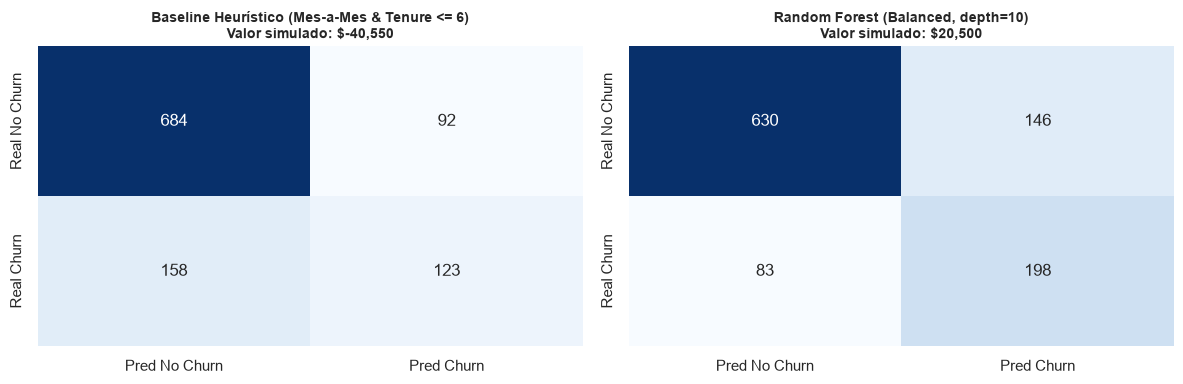

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

nombres_graficar = [
    "Baseline Heurístico (Mes-a-Mes & Tenure <= 6)",
    selected_model_name
]

for i, model_name in enumerate(nombres_graficar):
    row = df_test[
        df_test["Modelo"] == model_name
    ].iloc[0]

    cm = np.array([
        [row["TN"], row["FP"]],
        [row["FN"], row["TP"]]
    ])

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[i],
        xticklabels=["Pred No Churn", "Pred Churn"],
        yticklabels=["Real No Churn", "Real Churn"]
    )

    axes[i].set_title(
        f"{model_name}\n"
        f"Valor simulado: "
        f"${row['Valor Económico Neto ($)']:,.0f}",
        fontweight="bold",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### 9. Curvas del modelo seleccionado en Test

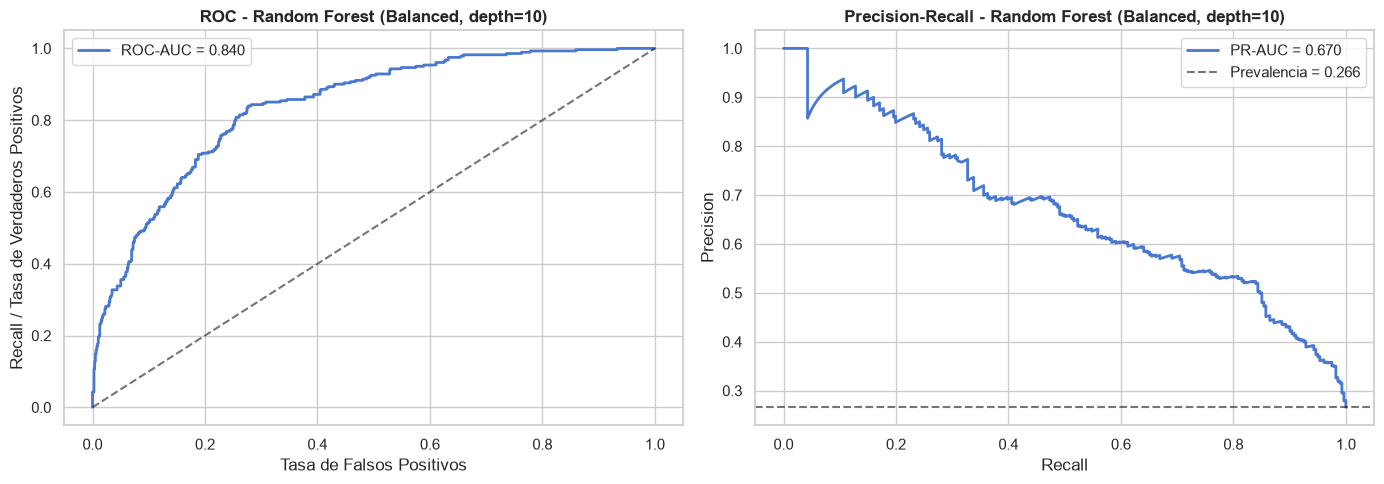

In [10]:
y_proba_test = final_test_probas[selected_model_name]

fpr, tpr, _ = roc_curve(
    y_test,
    y_proba_test
)

precision, recall, _ = precision_recall_curve(
    y_test,
    y_proba_test
)

roc_auc_test = roc_auc_score(
    y_test,
    y_proba_test
)

pr_auc_test = average_precision_score(
    y_test,
    y_proba_test
)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(
    fpr,
    tpr,
    lw=2,
    label=f"ROC-AUC = {roc_auc_test:.3f}"
)

ax[0].plot(
    [0, 1],
    [0, 1],
    "k--",
    alpha=0.6
)

ax[0].set_title(
    f"ROC - {selected_model_name}",
    fontweight="bold"
)

ax[0].set_xlabel("Tasa de Falsos Positivos")
ax[0].set_ylabel("Recall / Tasa de Verdaderos Positivos")
ax[0].legend()

ax[1].plot(
    recall,
    precision,
    lw=2,
    label=f"PR-AUC = {pr_auc_test:.3f}"
)

ax[1].axhline(
    y_test.mean(),
    color="k",
    linestyle="--",
    alpha=0.6,
    label=f"Prevalencia = {y_test.mean():.3f}"
)

ax[1].set_title(
    f"Precision-Recall - {selected_model_name}",
    fontweight="bold"
)

ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].legend()

plt.tight_layout()
plt.show()

### 10. Interpretación crítica de resultados

Con la ejecución reproducible actual (`random_state=42`):

- En **Validation**, Regresión Logística y Random Forest presentan PR-AUC muy similares.
- Random Forest queda seleccionado por una ventaja mínima en PR-AUC, por lo que debe considerarse un **candidato preliminar**, no una superioridad concluyente.
- En **Test**, el modelo seleccionado supera ampliamente al baseline trivial y al heurístico en PR-AUC.
- El valor económico presentado es una **simulación** basada en supuestos definidos por el grupo; no representa ganancias reales observadas.
- El Recall final debe compararse con la meta interna del proyecto de 0.75. Si queda por debajo, se reporta como una limitación y no se modifica el modelo mirando nuevamente Test.

Esta última decisión es importante: una vez utilizado Test para la evaluación final, no se debe volver a seleccionar modelos o ajustar hiperparámetros basándose en sus resultados.

In [11]:
# Resumen automático del modelo final para facilitar la interpretación.
selected_test_row = df_test[
    df_test["Modelo"] == selected_model_name
].iloc[0]

print("RESUMEN DEL CANDIDATO FINAL")
print("-" * 50)
print(f"Modelo: {selected_model_name}")
print(f"Accuracy:  {selected_test_row['Accuracy']:.4f}")
print(f"Precision: {selected_test_row['Precision (Clase 1)']:.4f}")
print(f"Recall:    {selected_test_row['Recall (Clase 1)']:.4f}")
print(f"F1-Score:  {selected_test_row['F1-Score']:.4f}")
print(f"ROC-AUC:   {selected_test_row['ROC-AUC']:.4f}")
print(f"PR-AUC:    {selected_test_row['PR-AUC']:.4f}")
print(
    "Valor económico simulado: "
    f"${selected_test_row['Valor Económico Neto ($)']:,.0f}"
)

if selected_test_row["Recall (Clase 1)"] >= 0.75:
    print("Meta interna Recall >= 0.75: CUMPLIDA")
else:
    print("Meta interna Recall >= 0.75: NO CUMPLIDA")

RESUMEN DEL CANDIDATO FINAL
--------------------------------------------------
Modelo: Random Forest (Balanced, depth=10)
Accuracy:  0.7833
Precision: 0.5756
Recall:    0.7046
F1-Score:  0.6336
ROC-AUC:   0.8400
PR-AUC:    0.6698
Valor económico simulado: $20,500
Meta interna Recall >= 0.75: NO CUMPLIDA


### 11. Estado del proyecto y plan hacia el Trabajo Final

#### Hallazgos actuales

- La prevalencia de `Churn` se mantiene cercana al 26.5%, por lo que Accuracy no debe interpretarse de forma aislada.
- Variables como tipo de contrato, antigüedad, servicio de internet, soporte técnico y método de pago muestran asociaciones relevantes en el EDA. Estas asociaciones no deben interpretarse como causalidad.
- Los modelos supervisados superan los baselines simples en capacidad de discriminación.
- Random Forest queda como candidato preliminar por PR-AUC en Validation, pero su ventaja frente a Regresión Logística es mínima.

#### Limitaciones identificadas

- Los hiperparámetros actuales no provienen todavía de una búsqueda sistemática.
- Se mantiene un umbral de decisión de 0.50.
- El resultado económico depende de supuestos de costos y beneficios definidos por el grupo.
- La estabilidad del desempeño aún no se ha evaluado mediante validación cruzada.
- El baseline heurístico proviene del análisis exploratorio del TP1; para una evaluación completamente ciega en trabajos futuros conviene definir reglas de dominio antes de observar el conjunto reservado.
- El dataset es transversal y no contiene historial transaccional suficiente para afirmar que se dispone de un CLV o RFM real.

#### Plan hacia el Trabajo Final

1. Implementar validación cruzada estratificada y búsqueda sistemática de hiperparámetros.
2. Comparar técnicas adicionales solo si son pertinentes al problema y a los datos.
3. Realizar ajuste de umbral y análisis detallado de falsos positivos y falsos negativos.
4. Incorporar interpretabilidad del modelo.
5. Evaluar segmentación usando únicamente variables disponibles y evitando presentar proxies como CLV/RFM real si el dataset no los soporta.
6. Construir un despliegue funcional y documentar el flujo completo de reproducción.

### 12. Conclusión del TP1

El TP1 deja un flujo reproducible de clasificación de churn con separación explícita entre Train, Validation y Test, preprocesamiento encapsulado en `Pipeline`, comparación de dos modelos supervisados, baselines de referencia y evaluación mediante métricas apropiadas para una clase positiva minoritaria.

El resultado actual debe interpretarse como **preliminar**. El objetivo del Trabajo Final será verificar su estabilidad, mejorar la experimentación y sustentar cualquier decisión de modelamiento con evidencia reproducible.